# Practical Exercise 2 - Task 1
# Vanilla GAN on MNIST using PyTorch

In this notebook, we implement a simple Vanilla GAN to generate MNIST-like digit images.

We will:
1. Load the MNIST dataset
2. Build the Generator and Discriminator
3. Train the GAN
4. Visualize generated samples

In [ ]:
# Standard library imports
import os
import random
from pathlib import Path

# Numerical and plotting imports
import numpy as np
import matplotlib.pyplot as plt

# PyTorch imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Weights & Biases
import wandb

from utils import device_check

## General setup

In [ ]:
LOG_WANDB = True
SEED = 1

# Paths
NOTEBOOK_DIR    = Path.cwd()          # e.g. .../src
PROJECT_DIR     = NOTEBOOK_DIR.parent  # parent folder of src
WANDB_DIR       = PROJECT_DIR
OUT_DIR         = PROJECT_DIR / "out"
MODELS_DIR      = PROJECT_DIR / "Models"

OUT_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Device setup
device = device_check()

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Enable cuDNN auto-tuner for fixed-size inputs
    torch.backends.cudnn.benchmark = True
    # Data loading settings
    PIN_MEMORY = True
    NUM_WORKERS = 16
else:
    # CPU optimization
    torch.set_num_threads(8)
    torch.set_num_interop_threads(8)

## Configuration

In [ ]:
# Training configuration
config = {
    "batch_size": 128,
    "latent_dim": 100,
    "g_hidden_dim": 128,
    "d_hidden_dim": 128,
    "image_dim": 28 * 28,
    "g_lr": 1e-3,
    "d_lr": 1e-3,
    "epochs": 100,
    "jupyter_plot_interval": 10,
    "wandb_image_interval": 1,
    "optimizer": "Adam",
    "betas": (0.9, 0.999),
    "dataset": "MNIST",
    "model": "Vanilla GAN",
    "seed": SEED
}

{'batch_size': 128,
 'latent_dim': 100,
 'g_hidden_dim': 128,
 'd_hidden_dim': 128,
 'image_dim': 784,
 'g_lr': 0.001,
 'd_lr': 0.001,
 'epochs': 100,
 'jupyter_plot_interval': 10,
 'wandb_image_interval': 1,
 'optimizer': 'Adam',
 'betas': (0.9, 0.999),
 'dataset': 'MNIST',
 'model': 'Vanilla GAN',
 'seed': 3}

## Helper function for readable checkpoint names

In [4]:
from datetime import datetime

# Build a readable file name for checkpoints
def build_model_name(config, task_name="task1", file_ext="pt"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    return (
        f"{task_name}"
        f"_ep{config['epochs']}"
        f"_bs{config['batch_size']}"
        f"_glr{config['g_lr']}"
        f"_dlr{config['d_lr']}"
        f"_gh{config['g_hidden_dim']}"
        f"_dh{config['d_hidden_dim']}"
        f"_seed{config['seed']}"
        f"_{timestamp}.{file_ext}"
    )

## Initialize Weights & Biases

In [5]:
# Shared W&B settings
WANDB_ENTITY = "d7047e-group12"
WANDB_PROJECT = "Lab2"

wandb_kwargs = dict(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name="Task1 - Vanilla GAN MNIST",
    tags=["Task 1", "GAN", "MNIST", "Vanilla GAN"],
    dir=str(WANDB_DIR),
    config=config,
    mode="online" if LOG_WANDB else "disabled",
)

wandb.login()
wandb.init(**wandb_kwargs)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: hamid-sabeti (d7047e-group12) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Load MNIST dataset

In [6]:
# Transform pipeline for MNIST
# ToTensor converts images to tensors in the range [0, 1]
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load the training set
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

# DataLoader handles batching and shuffling
train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

print("Number of training samples:", len(train_dataset))
print("Number of batches per epoch:", len(train_loader))

Number of training samples: 60000
Number of batches per epoch: 468


## Visualize a few real images

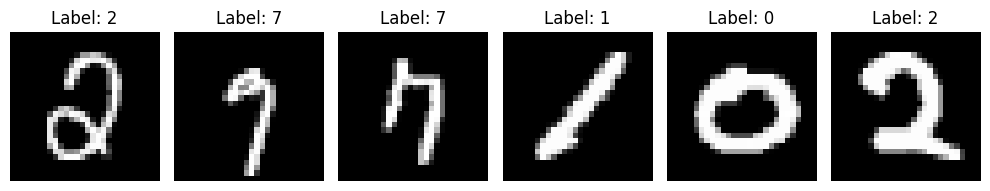

In [7]:
# Get one batch of real images
real_images, real_labels = next(iter(train_loader))

# Plot a few images from the batch
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(real_images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {real_labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Define the Generator network

In [8]:
# Generator network
# Input: latent noise vector
# Output: generated image vector of size 784

class Generator(nn.Module):
    def __init__(self, latent_dim, hidden_dim, image_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, image_dim),
            nn.Sigmoid()
        )

    def forward(self, z):
        return self.model(z)

## Define the Discriminator network

In [9]:
# Discriminator network
# Input: flattened image vector
# Output: probability that the image is real

class Discriminator(nn.Module):
    def __init__(self, image_dim, hidden_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(image_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

## Initialize models

In [10]:
# Create model instances and move them to device
G = Generator(
    latent_dim=config["latent_dim"],
    hidden_dim=config["g_hidden_dim"],
    image_dim=config["image_dim"]
).to(device)

D = Discriminator(
    image_dim=config["image_dim"],
    hidden_dim=config["d_hidden_dim"]
).to(device)

print(G)
print()
print(D)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=784, bias=True)
    (3): Sigmoid()
  )
)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1, bias=True)
    (3): Sigmoid()
  )
)


## Define the loss function and optimizers

In [11]:
# Binary cross entropy loss for Vanilla GAN
criterion = nn.BCELoss()

# Separate optimizers for Generator and Discriminator
g_optimizer = optim.Adam(
    G.parameters(),
    lr=config["g_lr"],
    betas=config["betas"]
)

d_optimizer = optim.Adam(
    D.parameters(),
    lr=config["d_lr"],
    betas=config["betas"]
)

## Helper function to visualize generated images

In [12]:
# Display generated images inside the notebook
def show_generated_images(generator, latent_dim, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    generator.train()

## Helper function for W&B image logging

In [13]:
# Create a matplotlib figure for W&B image logging
def make_generated_figure(generator, latent_dim, num_images=16):
    generator.eval()

    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    generator.train()
    return fig

## Helper function for saving final model

In [14]:
# Helper function to build a readable checkpoint name
from datetime import datetime

def build_model_name(config, task_name="task1", file_ext="pt"):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    model_name = (
        f"{task_name}"
        f"_model-{config['model'].replace(' ', '_')}"
        f"_data-{config['dataset']}"
        f"_ep-{config['epochs']}"
        f"_bs-{config['batch_size']}"
        f"_glr-{config['g_lr']}"
        f"_dlr-{config['d_lr']}"
        f"_gh-{config['g_hidden_dim']}"
        f"_dh-{config['d_hidden_dim']}"
        f"_seed-{config['seed']}"
        f"_{timestamp}.{file_ext}"
    )

    return model_name

## Save checkpoints at selected epochs

In [15]:
# Optional helper for saving images at specific epochs
# You can reuse this cell if you want to save outputs at 5, 10, and 50 epochs

def save_generated_grid(generator, latent_dim, save_path, num_images=16):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num_images, latent_dim, device=device)
        fake_images = generator(z).view(-1, 28, 28).cpu().numpy()

    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    for i, ax in enumerate(axes.flat):
        ax.imshow(fake_images[i], cmap="gray")
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.close(fig)
    generator.train()

## Train the Vanilla GAN

Epoch [1/100] | D_loss: 0.2436 | G_loss: 4.1658
Epoch [2/100] | D_loss: 0.0630 | G_loss: 5.1617
Epoch [3/100] | D_loss: 0.0890 | G_loss: 4.9712
Epoch [4/100] | D_loss: 0.1365 | G_loss: 4.1880
Epoch [5/100] | D_loss: 0.1263 | G_loss: 4.4980
Saved generated samples to: /root/D7047E/Lab2/out/task1_epoch_5.png
Epoch [6/100] | D_loss: 0.1586 | G_loss: 4.5077
Epoch [7/100] | D_loss: 0.2235 | G_loss: 4.6262
Epoch [8/100] | D_loss: 0.2516 | G_loss: 3.9905
Epoch [9/100] | D_loss: 0.3528 | G_loss: 3.8505
Epoch [10/100] | D_loss: 0.3574 | G_loss: 3.9402


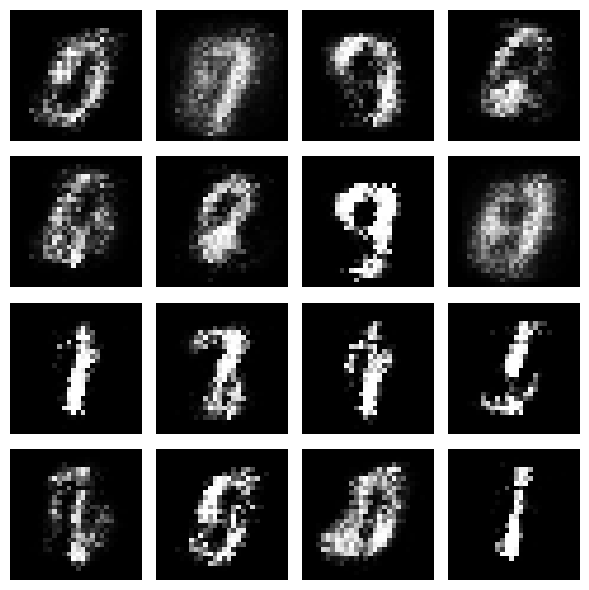

Saved generated samples to: /root/D7047E/Lab2/out/task1_epoch_10.png
Epoch [11/100] | D_loss: 0.4655 | G_loss: 3.9701
Epoch [12/100] | D_loss: 0.5650 | G_loss: 3.2581
Epoch [13/100] | D_loss: 0.5985 | G_loss: 2.9738
Epoch [14/100] | D_loss: 0.7156 | G_loss: 3.0586
Epoch [15/100] | D_loss: 0.7099 | G_loss: 2.9644
Epoch [16/100] | D_loss: 0.7480 | G_loss: 2.8071
Epoch [17/100] | D_loss: 0.7891 | G_loss: 3.0554
Epoch [18/100] | D_loss: 0.8509 | G_loss: 2.6439
Epoch [19/100] | D_loss: 0.8595 | G_loss: 2.5537
Epoch [20/100] | D_loss: 0.9407 | G_loss: 2.5060


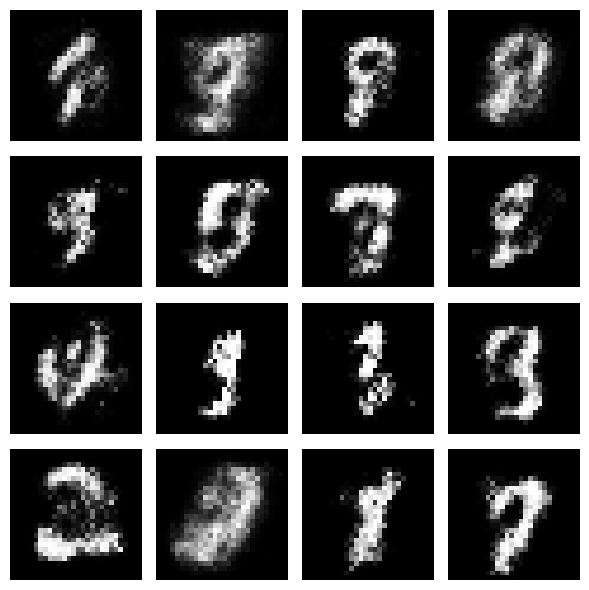

Epoch [21/100] | D_loss: 0.9772 | G_loss: 2.3420
Epoch [22/100] | D_loss: 0.9506 | G_loss: 2.2000
Epoch [23/100] | D_loss: 0.9934 | G_loss: 2.1828
Epoch [24/100] | D_loss: 0.9712 | G_loss: 1.9768
Epoch [25/100] | D_loss: 0.9167 | G_loss: 2.0361
Epoch [26/100] | D_loss: 0.9189 | G_loss: 1.9226
Epoch [27/100] | D_loss: 0.9638 | G_loss: 1.8619
Epoch [28/100] | D_loss: 0.9402 | G_loss: 1.8380
Epoch [29/100] | D_loss: 0.9427 | G_loss: 1.8903
Epoch [30/100] | D_loss: 0.9254 | G_loss: 1.8776


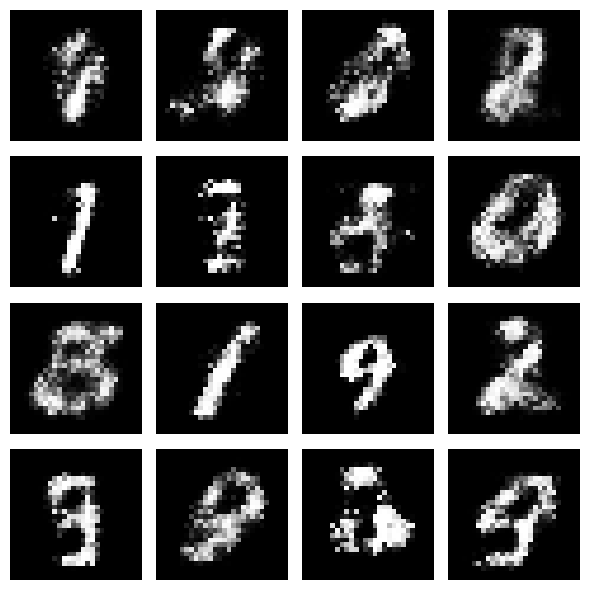

Epoch [31/100] | D_loss: 0.9134 | G_loss: 1.9280
Epoch [32/100] | D_loss: 0.9648 | G_loss: 1.7974
Epoch [33/100] | D_loss: 1.0013 | G_loss: 1.7387
Epoch [34/100] | D_loss: 0.9965 | G_loss: 1.7285
Epoch [35/100] | D_loss: 0.9933 | G_loss: 1.7934
Epoch [36/100] | D_loss: 0.9975 | G_loss: 1.7329
Epoch [37/100] | D_loss: 0.9973 | G_loss: 1.6968
Epoch [38/100] | D_loss: 0.9398 | G_loss: 1.7649
Epoch [39/100] | D_loss: 0.9800 | G_loss: 1.7686
Epoch [40/100] | D_loss: 0.9370 | G_loss: 1.7235


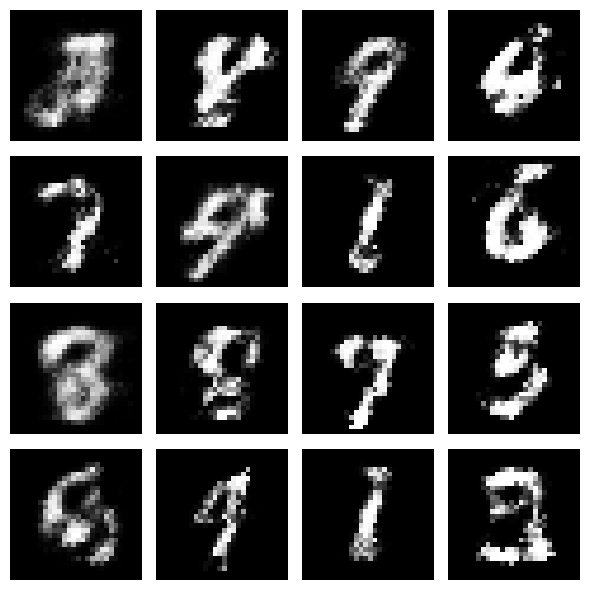

Epoch [41/100] | D_loss: 0.9676 | G_loss: 1.6550
Epoch [42/100] | D_loss: 0.9792 | G_loss: 1.7293
Epoch [43/100] | D_loss: 0.9642 | G_loss: 1.6679
Epoch [44/100] | D_loss: 0.9688 | G_loss: 1.6726
Epoch [45/100] | D_loss: 0.9363 | G_loss: 1.7396
Epoch [46/100] | D_loss: 0.9177 | G_loss: 1.7954
Epoch [47/100] | D_loss: 0.9584 | G_loss: 1.7095
Epoch [48/100] | D_loss: 0.9277 | G_loss: 1.6963
Epoch [49/100] | D_loss: 0.9051 | G_loss: 1.7862
Epoch [50/100] | D_loss: 0.9065 | G_loss: 1.8158


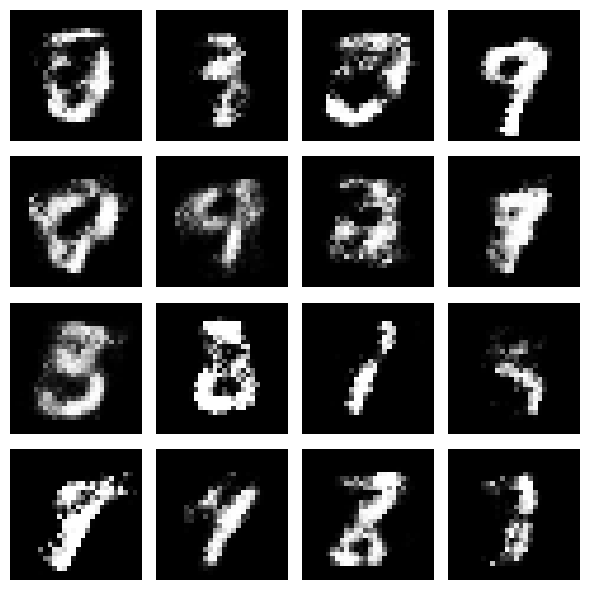

Saved generated samples to: /root/D7047E/Lab2/out/task1_epoch_50.png
Epoch [51/100] | D_loss: 0.9387 | G_loss: 1.7093
Epoch [52/100] | D_loss: 0.9115 | G_loss: 1.7442
Epoch [53/100] | D_loss: 0.9343 | G_loss: 1.6994
Epoch [54/100] | D_loss: 0.9297 | G_loss: 1.7319
Epoch [55/100] | D_loss: 0.9358 | G_loss: 1.7392
Epoch [56/100] | D_loss: 0.9424 | G_loss: 1.7149
Epoch [57/100] | D_loss: 0.9239 | G_loss: 1.7310
Epoch [58/100] | D_loss: 0.9268 | G_loss: 1.7676
Epoch [59/100] | D_loss: 0.9156 | G_loss: 1.7810
Epoch [60/100] | D_loss: 0.9453 | G_loss: 1.7109


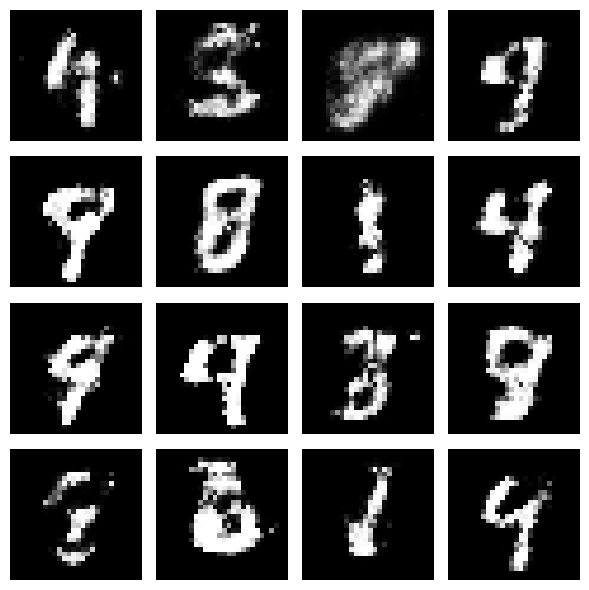

Epoch [61/100] | D_loss: 0.9337 | G_loss: 1.6917
Epoch [62/100] | D_loss: 0.9498 | G_loss: 1.7071
Epoch [63/100] | D_loss: 0.9293 | G_loss: 1.7292
Epoch [64/100] | D_loss: 0.9418 | G_loss: 1.6555
Epoch [65/100] | D_loss: 0.9266 | G_loss: 1.6498
Epoch [66/100] | D_loss: 0.9066 | G_loss: 1.7240
Epoch [67/100] | D_loss: 0.9068 | G_loss: 1.7199
Epoch [68/100] | D_loss: 0.9012 | G_loss: 1.7838
Epoch [69/100] | D_loss: 0.8754 | G_loss: 1.7933
Epoch [70/100] | D_loss: 0.8726 | G_loss: 1.8064


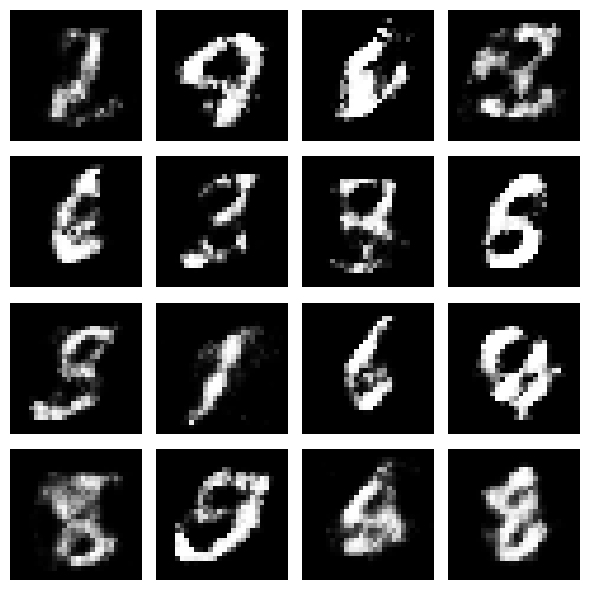

Epoch [71/100] | D_loss: 0.8910 | G_loss: 1.7833
Epoch [72/100] | D_loss: 0.8619 | G_loss: 1.8533
Epoch [73/100] | D_loss: 0.8782 | G_loss: 1.8315
Epoch [74/100] | D_loss: 0.8939 | G_loss: 1.8293
Epoch [75/100] | D_loss: 0.8600 | G_loss: 1.9096
Epoch [76/100] | D_loss: 0.8757 | G_loss: 1.9318
Epoch [77/100] | D_loss: 0.8681 | G_loss: 2.0059
Epoch [78/100] | D_loss: 0.8553 | G_loss: 2.0132
Epoch [79/100] | D_loss: 0.8584 | G_loss: 1.9909
Epoch [80/100] | D_loss: 0.8441 | G_loss: 2.0514


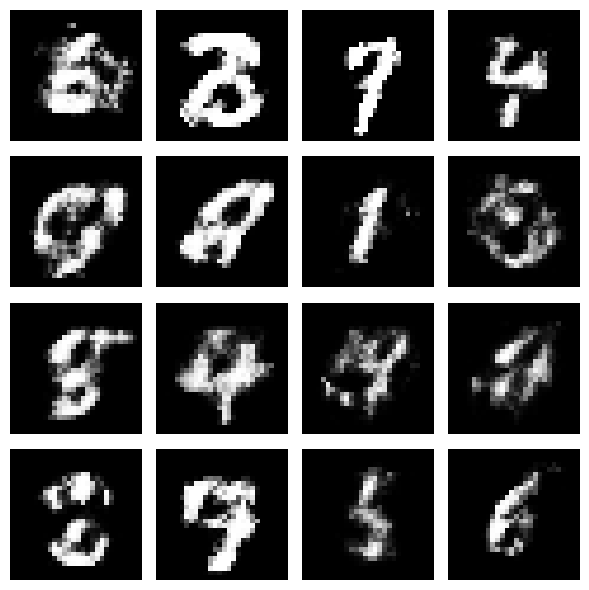

Epoch [81/100] | D_loss: 0.8423 | G_loss: 2.0302
Epoch [82/100] | D_loss: 0.8381 | G_loss: 2.0856
Epoch [83/100] | D_loss: 0.8343 | G_loss: 2.1153


In [ ]:
# Main training loop with epoch-level logging
# Also save generated samples at epochs 5, 10, 50, and 100

save_epochs = {5, 10, 50, 100}

for epoch in range(config["epochs"]):
    # Store batch losses for this epoch
    d_loss_list = []
    g_loss_list = []
    d_real_loss_list = []
    d_fake_loss_list = []

    for batch_idx, (real_images, _) in enumerate(train_loader):
        # Flatten images from [batch, 1, 28, 28] to [batch, 784]
        real_images = real_images.view(-1, config["image_dim"]).to(device, non_blocking=True)
        batch_size = real_images.size(0)

        # Create real and fake labels
        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        # =========================================================
        # 1) Train the Discriminator
        # =========================================================
        z = torch.randn(batch_size, config["latent_dim"], device=device)
        fake_images = G(z)

        d_real = D(real_images)
        d_fake = D(fake_images.detach())

        d_real_loss = criterion(d_real, real_labels)
        d_fake_loss = criterion(d_fake, fake_labels)
        d_loss = d_real_loss + d_fake_loss

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # =========================================================
        # 2) Train the Generator
        # =========================================================
        z = torch.randn(batch_size, config["latent_dim"], device=device)
        fake_images = G(z)

        d_fake_for_g = D(fake_images)
        g_loss = criterion(d_fake_for_g, real_labels)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

        # Store losses for epoch-level averaging
        d_loss_list.append(d_loss.item())
        g_loss_list.append(g_loss.item())
        d_real_loss_list.append(d_real_loss.item())
        d_fake_loss_list.append(d_fake_loss.item())

    # Compute average losses for the epoch
    avg_d_loss = np.mean(d_loss_list)
    avg_g_loss = np.mean(g_loss_list)
    avg_d_real_loss = np.mean(d_real_loss_list)
    avg_d_fake_loss = np.mean(d_fake_loss_list)

    # Print a clean epoch summary
    print(
        f"Epoch [{epoch + 1}/{config['epochs']}] | "
        f"D_loss: {avg_d_loss:.4f} | "
        f"G_loss: {avg_g_loss:.4f}"
    )

    # Log scalar metrics to W&B once per epoch
    wandb.log({
        "epoch": epoch + 1,
        "D_loss": avg_d_loss,
        "G_loss": avg_g_loss,
        "D_real_loss": avg_d_real_loss,
        "D_fake_loss": avg_d_fake_loss
    }, step=epoch + 1)

    # Log images to W&B every epoch if requested
    if (epoch + 1) % config["wandb_image_interval"] == 0:
        fig = make_generated_figure(G, config["latent_dim"], num_images=16)

        wandb.log({
            "generated_samples": wandb.Image(fig, caption=f"Epoch {epoch + 1}")
        }, step=epoch + 1)

        # Show images in Jupyter only every few epochs
        if (epoch + 1) % config["jupyter_plot_interval"] == 0:
            plt.show()

        plt.close(fig)

    # Save generated samples locally at selected epochs
    if (epoch + 1) in save_epochs:
        save_path = OUT_DIR / f"task1_epoch_{epoch + 1}.png"
        save_generated_grid(
            generator=G,
            latent_dim=config["latent_dim"],
            save_path=save_path,
            num_images=16
        )
        print(f"Saved generated samples to: {save_path}")

## Save trained models

In [ ]:
# Save a full training checkpoint
checkpoint_name = build_model_name(config, task_name="task1")
checkpoint_path = MODELS_DIR / checkpoint_name

torch.save({
    "task": "Task 1",
    "model_type": config["model"],
    "dataset": config["dataset"],
    "epoch": config["epochs"],
    "generator_state_dict": G.state_dict(),
    "discriminator_state_dict": D.state_dict(),
    "g_optimizer_state_dict": g_optimizer.state_dict(),
    "d_optimizer_state_dict": d_optimizer.state_dict(),
    "config": config,
    "device_used": str(device),
}, checkpoint_path)

print(f"Checkpoint saved to: {checkpoint_path}")

In [ ]:
# Save Generator weights only
generator_name = build_model_name(config, task_name="task1_generator")
generator_path = MODELS_DIR / generator_name

torch.save(G.state_dict(), generator_path)

print(f"Generator weights saved to: {generator_path}")

## Display final generated samples

In [ ]:
# Show final generated images after training
show_generated_images(G, config["latent_dim"], num_images=16)

## Finish the W&B run

In [ ]:
wandb.finish()